# Decision Tree Worksheet

In [55]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import graphviz
import matplotlib.pyplot as plt

## Loading data

Load Pima diabetes dataset and split data, with test size 20% and validaton 20%.

In [56]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

data = pd.read_csv(url, names=names)

invalid= ['plas','pres','skin','test','mass']

for i in invalid:
data[i] = data[i].replace(0, np.nan)

data=data.dropna(axis=0).reset_index(drop=True)
data.head()

X_cols= ['preg','plas', 'pres','skin','test','mass','pedi','age']
y_col='class'


test_size = 0.25
X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[y_col], test_size=test_size, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size, random_state=0)

/tmp/ipykernel_1525/2021849324.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].replace(to_replace=0, value=np.nan, inplace=True)


## Creating Model

Make a model using sklearn's DecisionTreeClassifier, with a high max-depth and low minimum sample leafs.

In [57]:
## YOUR CODE HERE
decision_tree = DecisionTreeClassifier(criterion = "entropy", random_state = 0,
                              max_depth=20, min_samples_leaf=1)

decision_tree.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=20, random_state=0)

Print accuracy of training and validation data.

In [58]:
## YOUR CODE HERE
y_train_pred=decision_tree.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=decision_tree.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  100.0
Validation Accuracy is  80.95238095238095


Make a model with a low max-depth and higher minimum sample leafs.

In [59]:
## YOUR CODE HERE
decision_tree = DecisionTreeClassifier(criterion = "entropy", random_state = 0,
                              max_depth=1, min_samples_leaf=20)

decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=1, min_samples_leaf=20)

Print accuracy of training and validation data.

In [60]:
## YOUR CODE HERE
y_train_pred=decision_tree.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=decision_tree.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  77.2
Validation Accuracy is  73.01587301587301


Explain the accuracy results below.

The second model had lower training and validation accuracy because its maximum depth was only 1, making the tree too simple. This caused underfitting because the model could not learn enough patterns from the data.

## Metrics

Plot the ROC curve and print the AUC of the second model.

Validation AUC: 0.7505434782608696


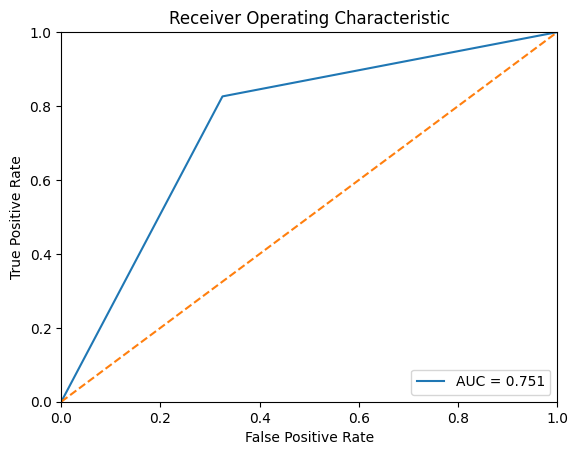

In [61]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_val_prob = decision_tree.predict_proba(X_val)

fpr, tpr, thresholds = roc_curve(y_val, y_val_prob[:, 1])
roc_auc = auc(fpr, tpr)

print("Validation AUC:", roc_auc)


plt.title("Receiver Operating Characteristic")
plt.plot(fpr, tpr, label="AUC = %0.3f" % roc_auc)
plt.legend(loc="lower right")
plt.plot([0, 1], [0, 1], "--")
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.show()

Use graphviz to visualize your 2nd tree.

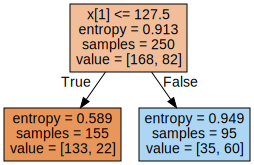

In [62]:
## YOUR CODE HERE
dot_data = tree.export_graphviz(decision_tree, out_file=None, filled=True)

graph = graphviz.Source(dot_data)
graph

#### Use the graph above to answer the questions below

Question 1: What do you think X[n] represents in the nodes from the graph?

X[n] represents a feature column from the input dataset. The number n is the index of that feature in X_train.

Question 2: What is the root feature? Does it make sense as the root feature?

The root feature is X[1], which represents plasma glucose concentration, or "plas." It makes sense as the root feature because blood glucose is strongly related to whether a patient has diabetes.

Question 3: If you were to change the parameters to have a max_depth of 500 and min_samples_leaf of 1, what do you think the effect would be on the test accuracy? Training accuracy?

Increasing max_depth to 500 and reducing min_samples_leaf to 1 would allow the tree to become extremely complex. The training accuracy would likely reach or approach 100%, while the test accuracy might remain the same or decrease because the model could overfit the training data.


**Test your guesses, create a model with max_depth=500 and min_samples_leaf=1, and predict values for the training and validation data**

In [63]:
## YOUR CODE HERE
decision_tree = DecisionTreeClassifier(criterion = "entropy", random_state = 0,
                              max_depth=500, min_samples_leaf=1)

decision_tree.fit(X_train, y_train)

y_train_pred=decision_tree.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=decision_tree.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  100.0
Validation Accuracy is  80.95238095238095


# Random Forest

## Creating Model

Create a model with sklearn's RandomForestClassifier and predict values on your validation set.

In [64]:
## YOUR CODE HERE
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, y_train)

RandomForestClassifier()

Print accuracy of training and validation data.

In [65]:
## YOUR CODE HERE
y_train_pred = random_forest.predict(X_train)
print("Training Accuracy is", accuracy_score(y_train, y_train_pred) * 100)
y_val_pred = random_forest.predict(X_val)
print("Validation Accuracy is", accuracy_score(y_val, y_val_pred) * 100)

Training Accuracy is 100.0
Validation Accuracy is 77.77777777777779


How did the accuracy compare to the decision tree's accuracy?

The Random Forest achieved 77.78% validation accuracy, which was lower than the deeper Decision Tree’s validation accuracy of 80.95%, but higher than the shallow Decision Tree’s accuracy of 73.02%. Although Random Forests often reduce overfitting, they do not always achieve higher accuracy on every validation split.


Print the 3 most important features (hint: sklearn has an attribute to help you find these)

In [66]:
## YOUR CODE HERE
feature_importance = pd.Series(
    random_forest.feature_importances_,
    index=X_train.columns
)

top3 = feature_importance.sort_values(ascending=False).head(3)

print("Top 3 Most Important Features:")
print(top3)

Top 3 Most Important Features:
plas    0.241636
test    0.167831
age     0.128978
dtype: float64


Find the accuracy for random forests with 1 to 100 trees, counting by 5. Print and then plot these accuracies.

1 trees: 0.6667
6 trees: 0.7302
11 trees: 0.6825
16 trees: 0.7778
21 trees: 0.7778
26 trees: 0.7619
31 trees: 0.8095
36 trees: 0.8254
41 trees: 0.8254
46 trees: 0.7937
51 trees: 0.7937
56 trees: 0.7778
61 trees: 0.7778
66 trees: 0.7778
71 trees: 0.7619
76 trees: 0.7778
81 trees: 0.7778
86 trees: 0.7778
91 trees: 0.7778
96 trees: 0.7778


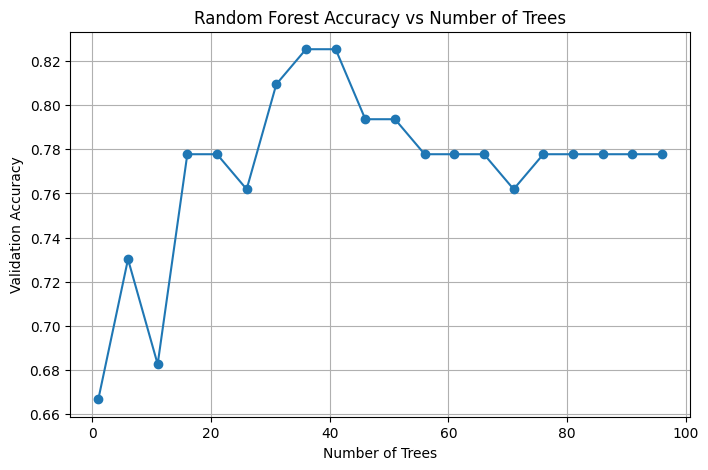

In [67]:
## YOUR CODE HERE
tree_counts = list(range(1, 101, 5))
accuracies = []

for n in tree_counts:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=0
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)

    acc = accuracy_score(y_val, y_pred)

    accuracies.append(acc)

    print(f"{n} trees: {acc:.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(tree_counts, accuracies, marker='o')
plt.title("Random Forest Accuracy vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.show()

Plot the roc_curve using predict_proba a function for our random forest model, and metrics.roc_curve

It might help to google these functions and look at sklearn's documentation.

Validation AUC: 0.8793478260869565


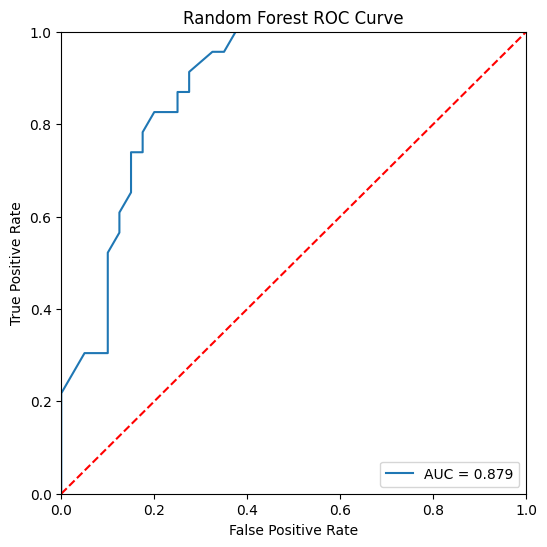

In [68]:
## YOUR CODE HERE

from sklearn.metrics import roc_curve, auc

y_prob = random_forest.predict_proba(X_val)

fpr, tpr, thresholds = metrics.roc_curve(y_val, y_prob[:,1])

roc_auc = auc(fpr, tpr)

print("Validation AUC:", roc_auc)

plt.figure(figsize=(6,6))
plt.title("Random Forest ROC Curve")
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()